In [1]:
from bdschism.ccf_gate_height import ccf_gate,sffpx_level

In [2]:
model_start = "2018-08-14"

model_end = "2018-08-20"

#model_end = "2021-10-01"

#for DCP

export_file = "./flux_0065.th"

#Lily sent me the astro_file

astro_file = "/home/jisrael/Savio_scratch_back_up/scripts/preprocessing_scripts/dms_oh4_elev@harmonic_2001_2025.csv"

#sf_data_repo = "//cnrastore-bdo/Modeling_Data/repo/continuous/screened/"
#sf_data_repo = "/expanse/lustre/scratch/jisrael/temp_project/validation_data/screened/"
sffpx_datasrc = "/expanse/lustre/scratch/jisrael/temp_project/forcing_data_big/sffpx/dms_sffpx_elev.csv"
plot = True

#sffpx_elev=sffpx_level(model_start, model_end, sf_data_repo)
#update 04/04/2026
sffpx_elev = sffpx_level(model_start, model_end, sffpx_datasrc)
sffpx_elev

Reading sffpx data from file(s): /expanse/lustre/scratch/jisrael/temp_project/forcing_data_big/sffpx/dms_sffpx_elev.csv


,elev
datetime,
2018-08-09 00:00:00,0.914
2018-08-09 00:06:00,0.853
2018-08-09 00:12:00,0.794
2018-08-09 00:18:00,0.733
2018-08-09 00:24:00,0.670
...,...
2018-08-24 23:36:00,1.666
2018-08-24 23:42:00,1.641
2018-08-24 23:48:00,1.612


The input export dt is Daily
Making priorities from tide
Saving predicted gate height file to ./ccfb_DCP_dated_short_fixed.th


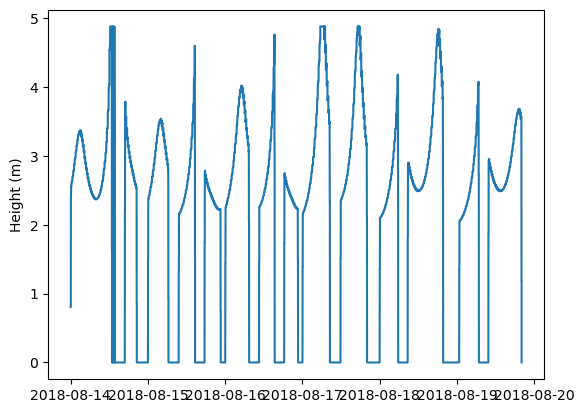

In [3]:
# dest='./ccfb_DCP_dated_short_fixed.th'
# plot=True
# save_intermediate=True
# ccf_gate(model_start,model_end,dest,astro_file,export_file,sffpx_elev,plot,save_intermediate)

In [ ]:
#try running the short file again

The input export dt is Daily
Making priorities from tide
Saving predicted gate height file to ./ccfb_DCP_dated_2026_04_04_short.th


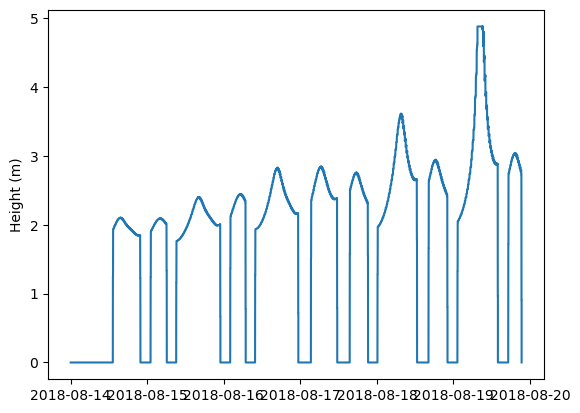

In [4]:
dest='./ccfb_DCP_dated_2026_04_04_short.th'
plot=True
save_intermediate=True
ccf_gate(model_start,model_end,dest,astro_file,export_file,sffpx_elev,plot,save_intermediate)

Reading sffpx data from file(s): /expanse/lustre/scratch/jisrael/temp_project/forcing_data_big/sffpx/dms_sffpx_elev.csv
The input export dt is Daily
Making priorities from tide
Saving predicted gate height file to /home/jisrael/Savio_scratch_back_up/scenario_files/DCP/data/time_history/ccfb_DCP_dated_2026_04_04.th


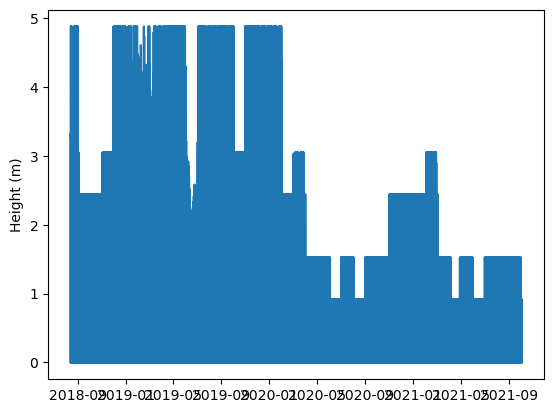

In [9]:
# try the full file
model_start = "2018-08-14"
model_end = "2021-10-03"
dest='/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/data/time_history/ccfb_DCP_dated_2026_04_04.th'
export_file = "/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/data/time_history/flux_s0065.th.ported"
sffpx_elev = sffpx_level(model_start, model_end, sffpx_datasrc)
plot=True
save_intermediate=True
ccf_gate(model_start,model_end,dest,astro_file,export_file,sffpx_elev,plot,save_intermediate)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# is this file different from the old version around June 19-24 2019?
dtformat = '%Y-%m-%dT%H:%M'
new=pd.read_csv("~/Savio_scratch_back_up/scenario_files/DCP/data/time_history/ccfb_DCP_dated_2026_04_04.th",
                sep=' ')
new['datetime']=pd.to_datetime(new['datetime'],format=dtformat)
old=pd.read_csv("~/Savio_scratch_back_up/scenario_files/DCP/data/time_history/ccfb_DCP_dated_full_03_19_2026.th",
                sep=' ')
old['datetime']=pd.to_datetime(old['datetime'],format=dtformat)
new

,datetime,install,ndup,op_down,op_up,elev,width,height
0,2018-08-14 00:00:00,1,5,1.0,0.0,-4.024,6.096,0.000
1,2018-08-14 00:02:00,1,5,1.0,0.0,-4.024,6.096,0.812
2,2018-08-14 00:04:00,1,5,1.0,0.0,-4.024,6.096,1.623
3,2018-08-14 00:06:00,1,5,1.0,0.0,-4.024,6.096,2.435
4,2018-08-14 00:08:00,1,5,1.0,0.0,-4.024,6.096,2.540
...,...,...,...,...,...,...,...,...
212584,2021-10-02 21:24:00,1,5,1.0,0.0,-4.024,6.096,0.610
212585,2021-10-02 21:26:00,1,5,1.0,0.0,-4.024,6.096,0.914
212586,2021-10-02 21:36:00,1,5,1.0,0.0,-4.024,6.096,0.610
212587,2021-10-02 21:38:00,1,5,1.0,0.0,-4.024,6.096,0.305


In [4]:
new.dtypes

datetime    datetime64[us]
install              int64
ndup                 int64
op_down            float64
op_up              float64
elev               float64
width              float64
height             float64
dtype: object

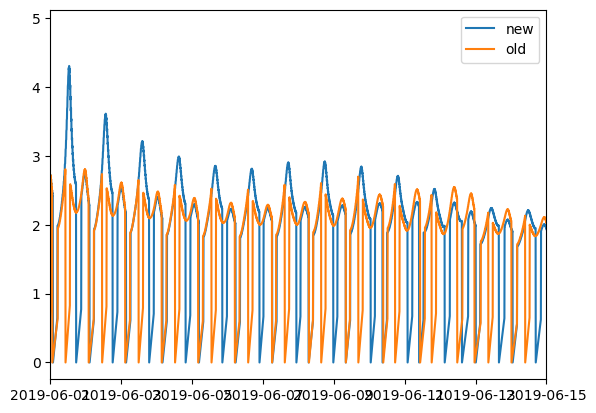

In [5]:
fig, ax = plt.subplots()
ax.plot(new.datetime,new.height,label='new')
ax.plot(old.datetime,old.height,label='old')
ax.set_xlim(pd.to_datetime('2019-06-01'),pd.to_datetime('2019-06-15'))
ax.legend()